In [7]:
import pandas as pd
df = pd.read_excel('../data/data.xlsx')

# 1. View number of rows and columns
print("Shape of dataset (rows, columns):", df.shape)

# 3. List all columns with data types
print("\nColumn Data Types:")
print(df.dtypes)





Shape of dataset (rows, columns): (95662, 16)

Column Data Types:
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode             float64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                   float64
TransactionStartTime     object
PricingStrategy         float64
FraudResult               int64
dtype: object


In [8]:
# Show only columns with missing values and their counts
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

AccountId               2
CountryCode             2
ProviderId              2
Value                   3
TransactionStartTime    1
PricingStrategy         3
dtype: int64


In [9]:
# Fill missing values with column mean for numeric columns, and mode for object columns

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            # Fill with mode (most frequent value) for categorical columns
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            # Fill with mean for numeric columns
            df[col].fillna(df[col].mean(), inplace=True)

# Check again for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values after filling:")
print(missing)

Missing values after filling:
Series([], dtype: int64)


C:\Users\user\AppData\Local\Temp\ipykernel_13464\2202160232.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_13464\2202160232.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [10]:
# Show only columns with missing values and their counts
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Series([], dtype: int64)


In [12]:
# Save the cleaned DataFrame to the processed folder as an Excel file
df.to_excel('../data/processed.xlsx', index=False)

Correlation Matrix:
                 CountryCode    Amount     Value  PricingStrategy  \
CountryCode              NaN       NaN       NaN              NaN   
Amount                   NaN  1.000000  0.989692        -0.061936   
Value                    NaN  0.989692  1.000000        -0.017017   
PricingStrategy          NaN -0.061936 -0.017017         1.000000   
FraudResult              NaN  0.557370  0.566739        -0.033820   
CountryCode_num          NaN       NaN       NaN              NaN   

                 FraudResult  CountryCode_num  
CountryCode              NaN              NaN  
Amount              0.557370              NaN  
Value               0.566739              NaN  
PricingStrategy    -0.033820              NaN  
FraudResult         1.000000              NaN  
CountryCode_num          NaN              NaN  


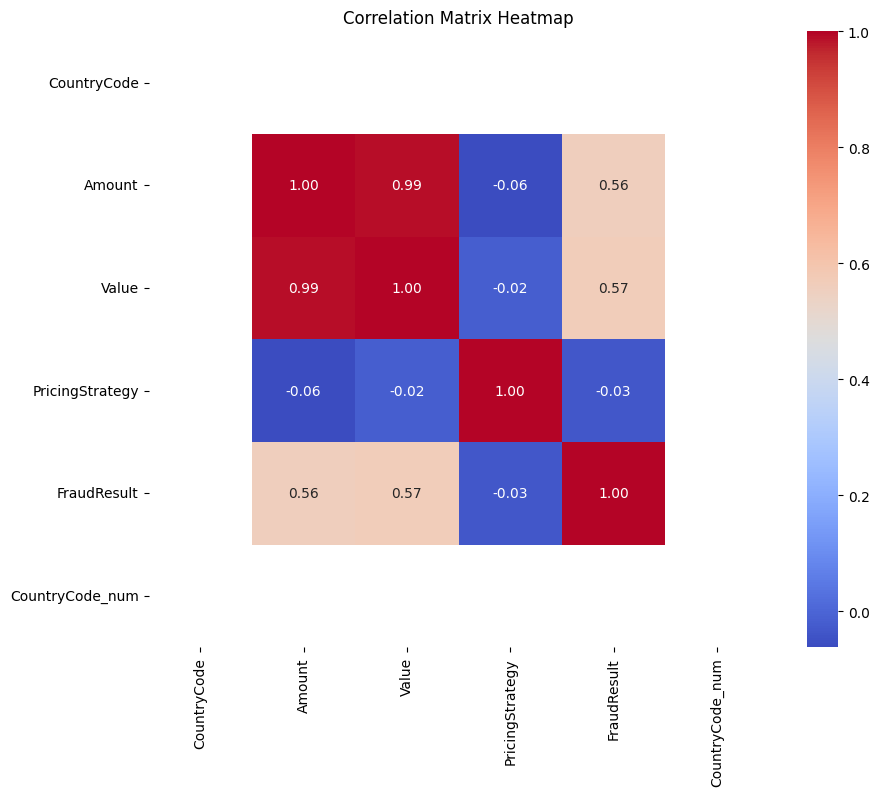

In [6]:
# Correlation Analysis
# Understanding the relationship between numerical features.

import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix for numerical features
corr_matrix = df.corr(numeric_only=True)

# Display the correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

# Plot a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [2]:
import pandas as pd
df = pd.read_excel('../data/processed.xlsx')

In [5]:
# Automatically find columns with categorical (object) data type
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical columns:", categorical_cols)


Categorical columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId']


In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load your dataset
df = pd.read_excel('../data/processed.xlsx')

# List of categorical columns
categorical_cols = [
    'TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId',
    'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId'
]

# Dictionary to store encoders
label_encoders = {}

# Apply Label Encoding and store encoders
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_label'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [7]:
# Select only columns with a small number of unique values
low_card_cols = [col for col in categorical_cols if df[col].nunique() < 50]

print("One-hot encoding these:", low_card_cols)



One-hot encoding these: ['CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId']


In [8]:
df_one_hot = pd.get_dummies(df[low_card_cols], drop_first=True)


In [9]:
# 1. Identify low-cardinality columns
low_card_cols = [col for col in categorical_cols if df[col].nunique() < 50]

# 2. One-Hot Encode them
df_one_hot = pd.get_dummies(df[low_card_cols], drop_first=True)

# 3. Combine label-encoded + one-hot
df_combined = pd.concat([df, df_one_hot], axis=1)

# 4. Drop original object columns if desired
df_combined = df_combined.drop(columns=categorical_cols)

print("✅ Encoding complete. Final shape:", df_combined.shape)


✅ Encoding complete. Final shape: (95662, 63)


In [10]:
print("🔍 Non-numeric columns remaining:", df_combined.select_dtypes(include='object').columns.tolist())
print("🔢 Final shape of data:", df_combined.shape)


🔍 Non-numeric columns remaining: []
🔢 Final shape of data: (95662, 63)


In [11]:
from sklearn.preprocessing import MinMaxScaler  # or StandardScaler
import pandas as pd


In [13]:
from sklearn.preprocessing import MinMaxScaler

# Select only numeric columns (int and float)
numeric_cols = df_combined.select_dtypes(include=['number']).columns

scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_combined[numeric_cols]),
    columns=numeric_cols
)

print(df_normalized.head())

   CountryCode    Amount     Value  PricingStrategy  FraudResult  \
0          0.0  0.092004  0.000101              0.5          0.0   
1          0.0  0.092250  0.000002              0.5          0.0   
2          0.0  0.091958  0.000050              0.5          0.0   
3          0.0  0.093750  0.001002              0.5          0.0   
4          0.0  0.091853  0.000065              0.5          0.0   

   TotalTransactionAmount  AverageTransactionAmount  TransactionCount  \
0                0.557541                  0.047188          0.028851   
1                0.557541                  0.047188          0.028851   
2                0.556944                  0.047137          0.000244   
3                0.558153                  0.047749          0.009046   
4                0.558153                  0.047749          0.009046   

   StdDevTransactionAmount  MaxTransactionAmount  ...  TransactionId_label  \
0                 0.000922              0.021825  ...             0.816947

In [14]:
df_normalized.to_csv("../data/final.csv", index=False)
print("✅ Normalized data saved as final.csv")


✅ Normalized data saved as final.csv
